# **Proyecto 4 - EDA con Python**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Para mostrar todas las columnas del DataFrame cuando lo imprima

pd.set_option('display.max_columns', None)

In [3]:
# Leer los datos

bank = pd.read_csv("C:/Users/ivida/OneDrive/Escritorio/raq/ThePower/Proyecto 4 - EDA con Python/Raw Data/bank-additional.csv")

customer = pd.ExcelFile("C:/Users/ivida/OneDrive/Escritorio/raq/ThePower/Proyecto 4 - EDA con Python/Raw Data/customer-details.xlsx")

clientes_2012 = pd.read_excel(customer, sheet_name="2012")
clientes_2013 = pd.read_excel(customer, sheet_name="2013")
clientes_2014 = pd.read_excel(customer, sheet_name="2014")

In [4]:
# Vamos a unir las 3 hojas del excel clientes

clientes = pd.concat(
    [clientes_2012, clientes_2013, clientes_2014],
    ignore_index=True
)

In [5]:
# Comprobamos tamaño del excel clientes una vez unidas las tres hojas

clientes.shape

(43170, 7)

In [6]:
bank.shape

(43000, 24)

**Exploración inicial de los archivos**

In [7]:
# Vamos a hacer una exploración inicial de los archivos. Empezamos con la base de datos de los bancos y luego la de los clientes.

bank.info()

bank.describe()

bank.head()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  str    
 3   marital         42915 non-null  str    
 4   education       41193 non-null  str    
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  str    
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  str    
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  str    
 16  cons.conf.idx   43000 non-null  str    
 17  euribor3m       33744 non-null  str    
 1

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [8]:
# Para saber cuantos valores nulos hay en cada columna en la base de datos del banco

bank.isnull().sum()

Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

In [9]:
clientes.info()

clientes.describe()

clientes.head()

<class 'pandas.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[us]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  str           
dtypes: datetime64[us](1), int64(5), str(1)
memory usage: 2.3 MB


,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [10]:
clientes.isnull().sum()

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

**Limpieza de datos**

In [11]:
# Vamos a eliminar columnas que no nos sirven

bank.drop(columns=["Unnamed: 0"], inplace=True)

clientes.drop(columns=["Unnamed: 0"], inplace=True)

In [12]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [13]:
clientes.head()

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


**Corregimos nombres de las columnas**

In [14]:
bank.columns = bank.columns.str.lower().str.strip()
clientes.columns = clientes.columns.str.lower().str.strip()

**Corregimos el tipo de variable de algunas columnas**

In [15]:
# Convertimos columnas que son strings a variables float, ya que no tiene sentido que sean string.
columnas_float = [
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

bank[columnas_float] = (
    bank[columnas_float]
    .replace(',', '.', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

In [16]:
bank[columnas_float].dtypes

cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
dtype: object

In [17]:
# El número de empleados tampoco tiene sentido que sea una string en vez de un integer.

bank['nr.employed'] = bank['nr.employed'].astype(int)

In [18]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [19]:
# La columna "date" también es una variable tipo string. La vamos a cambiar a tipo fecha.

meses = {
    'enero':'January',
    'febrero':'February',
    'marzo':'March',
    'abril':'April',
    'mayo':'May',
    'junio':'June',
    'julio':'July',
    'agosto':'August',
    'septiembre':'September',
    'octubre':'October',
    'noviembre':'November',
    'diciembre':'December'
}

for esp, eng in meses.items():
    bank['date'] = bank['date'].str.replace(esp, eng, regex=False)

bank['date'] = pd.to_datetime(
    bank['date'],
    errors='coerce'
)

In [20]:
bank['date'].dtype

dtype('<M8[us]')

In [21]:
# Las columnas default, housing y loan son tipo float y las vamos a transformar en variables categóricas

columnas_binarias = ['default', 'housing', 'loan']

bank[columnas_binarias] = (
    bank[columnas_binarias].replace({1.0: 'Yes', 0.0: 'No'})
)

for col in columnas_binarias:
    bank[col] = bank[col].astype('category')

In [22]:
bank[columnas_binarias].dtypes

default    category
housing    category
loan       category
dtype: object

In [23]:
# También transformamos la columna "y" ya que sale como númerica y no lo es, es categórica.

bank['y'] = bank['y'].astype('category')
bank['y'].dtypes

CategoricalDtype(categories=['no', 'yes'], ordered=False, categories_dtype=str)

**Correcciones valores nulos**


In [24]:
# Primero calculamos el % de nulos que hay en cada variable

porcentaje_nulos = (
    bank.isnull().sum()
    / len(bank)
    * 100
)

In [25]:
df_tabla_nulos = pd.DataFrame(porcentaje_nulos, columns = ["Porcentaje"])
df_tabla_nulos

,Porcentaje
age,11.906977
job,0.802326
marital,0.197674
education,4.202326
default,20.886047
housing,2.386047
loan,2.386047
contact,0.000000
duration,0.000000
campaign,0.000000


In [26]:
# Para columna age vamos a rellenar los nulos con la mediana. Utilizamos la mediana porque la edad suele tener outliers y la mediana es más robusta.

bank['age'] = bank['age'].fillna(
    bank['age'].median()
)

In [27]:
bank['age'].isnull().sum()

np.int64(0)

In [28]:
# Para job, marital, date y education vamos a poner "unknown" para los valores nulos

bank['job'] = bank['job'].fillna('Unknown')
bank['marital'] = bank['marital'].fillna('Unknown')
bank['education'] = bank['education'].fillna('Unknown')

In [29]:
bank['education'].isnull().sum()

np.int64(0)

In [30]:
# Para default vamos a ver cuantos No y Sí hay. Luego rellenaremos con "unknown" porque no sabemos realmente si el cliente tenía o no impagos.

bank['default'].value_counts(dropna=False)

default
No     34016
NaN     8981
Yes        3
Name: count, dtype: int64

In [31]:
bank['default'] = bank['default'].cat.add_categories(['Unknown'])


In [32]:
bank['default'] = bank['default'].fillna('Unknown')

In [33]:
bank['default'].isnull().sum()

np.int64(0)

In [34]:
# Vamos a hacer lo mismo con housing y loan

bank['housing'] = bank['housing'].cat.add_categories(['Unknown'])


In [35]:

bank['housing'] = bank['housing'].fillna('Unknown')

In [36]:
bank['housing'].isnull().sum()

np.int64(0)

In [37]:
bank['loan'] = bank['loan'].cat.add_categories(['Unknown'])

In [38]:
bank['loan'] = bank['loan'].fillna('Unknown')

In [39]:
bank['loan'].isnull().sum()

np.int64(0)

In [40]:
# Para cons.price.idx son pocos los nulos, así que podemos hacer como con la variable edad y utilizar la mediana. 

bank['cons.price.idx'] = bank['cons.price.idx'].fillna(
    bank['cons.price.idx'].median()
)

In [41]:
bank['cons.price.idx'].isnull().sum()

np.int64(0)

In [42]:
# euribor3m - Tiene muchos nulos así que vamos a comprobar la descripción y si los nulos están relacionados con alguna fecha.

bank['euribor3m'].describe()

count    33744.000000
mean         3.616521
std          1.737117
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64

In [43]:
# Vamos a crear las columnas contact_year y contact_month que salen en el enunciado del Word pero no en el csv.

bank['contact_year'] = bank['date'].dt.year
bank['contact_month_name'] = bank['date'].dt.month_name()

In [44]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_year,contact_month_name
0,38.0,housemaid,MARRIED,basic.4y,No,No,No,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,2019.0,August
1,57.0,services,MARRIED,high.school,Unknown,No,No,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,2016.0,September
2,37.0,services,MARRIED,high.school,No,Yes,No,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019.0,February
3,40.0,admin.,MARRIED,basic.6y,No,No,No,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,2015.0,November
4,56.0,services,MARRIED,high.school,No,No,Yes,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2017.0,January


In [45]:
bank.groupby('contact_year')['euribor3m'].apply(
    lambda x: x.isna().mean()*100
)

contact_year
2015.0    21.828184
2016.0    21.586781
2017.0    20.205559
2018.0    21.242251
2019.0    22.723027
Name: euribor3m, dtype: float64

In [46]:
# Los nulos no parecen depender del año. Eso significa que probablemente:

# No es un problema de una carga concreta.
# No es que falten datos de un año determinado.
# Parece una ausencia de información distribuida de forma bastante aleatoria.

Los clientes que contrataron el depósito presentan valores de euribor3m significativamente inferiores a los clientes que no contrataron el producto (mediana de 1.266 frente a 4.857), lo que sugiere una posible relación entre los tipos de interés y la probabilidad de contratación.

In [47]:
bank.groupby('y')['euribor3m'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
y,,,
no,29899,3.810591,4.857
yes,3845,2.107420,1.266


**Fusión de los dos datasets**

In [48]:
# Primero miramos que los IDs sean únicos

bank['id_'].nunique()


43000

In [49]:
clientes['id'].nunique()

43170

In [50]:
# Vamos a ver si hay duplicados

bank['id_'].duplicated().sum()

np.int64(0)

In [51]:
clientes['id'].duplicated().sum()

np.int64(0)

In [52]:
# Ahora comprobamos cuántos IDs coinciden

test_merge = bank.merge(
    clientes,
    left_on='id_',
    right_on='id',
    how='left',
    indicator=True
)

test_merge['_merge'].value_counts()

_merge
both          43000
left_only         0
right_only        0
Name: count, dtype: int64

In [53]:
# Ahora hacemos el merge definitivo

df_bank_clientes = bank.merge(
    clientes,
    left_on='id_',
    right_on='id',
    how='left'
)

In [54]:
df_bank_clientes.shape

(43000, 31)

In [55]:
df_bank_clientes.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_year,contact_month_name,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,id
0,38.0,housemaid,MARRIED,basic.4y,No,No,No,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,2019.0,August,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,Unknown,No,No,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,2016.0,September,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,No,Yes,No,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019.0,February,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,No,No,No,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,2015.0,November,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,No,No,Yes,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2017.0,January,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [56]:
# Como salen dos columnas de ID una vez fusionadas, vamos a quitar una de ellas.
df_bank_clientes.drop(columns=['id'], inplace=True)

In [57]:
df_bank_clientes.head()

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_,contact_year,contact_month_name,income,kidhome,teenhome,dt_customer,numwebvisitsmonth
0,38.0,housemaid,MARRIED,basic.4y,No,No,No,telephone,261,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,2019.0,August,161770,1,0,2012-04-04,29
1,57.0,services,MARRIED,high.school,Unknown,No,No,telephone,149,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,2016.0,September,85477,1,1,2012-12-30,7
2,37.0,services,MARRIED,high.school,No,Yes,No,telephone,226,1,999,0,NONEXISTENT,1.1,93.994,-36.4,4.857,5191,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019.0,February,147233,1,1,2012-02-02,5
3,40.0,admin.,MARRIED,basic.6y,No,No,No,telephone,151,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,2015.0,November,121393,1,2,2012-12-21,29
4,56.0,services,MARRIED,high.school,No,No,Yes,telephone,307,1,999,0,NONEXISTENT,1.1,93.994,-36.4,NaN,5191,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2017.0,January,63164,1,2,2012-06-20,20


**Guardar los nuevos archivos**

In [95]:
bank.to_excel("C:/Users/ivida/OneDrive/Escritorio/raq/ThePower/Proyecto 4 - EDA con Python/Clean Data/bank_clean.xlsx", index=False)

clientes.to_excel("C:/Users/ivida/OneDrive/Escritorio/raq/ThePower/Proyecto 4 - EDA con Python/Clean Data/clientes_clean.xlsx", index=False)

df_bank_clientes.to_excel("C:/Users/ivida/OneDrive/Escritorio/raq/ThePower/Proyecto 4 - EDA con Python/Clean Data/df_bank_clientes.xlsx", index=False)

**Análisis Descriptivo**

*Visión general del dataset*

In [58]:
df_bank_clientes.shape

(43000, 30)

In [59]:
df_bank_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   age                 43000 non-null  float64       
 1   job                 43000 non-null  str           
 2   marital             43000 non-null  str           
 3   education           43000 non-null  str           
 4   default             43000 non-null  category      
 5   housing             43000 non-null  category      
 6   loan                43000 non-null  category      
 7   contact             43000 non-null  str           
 8   duration            43000 non-null  int64         
 9   campaign            43000 non-null  int64         
 10  pdays               43000 non-null  int64         
 11  previous            43000 non-null  int64         
 12  poutcome            43000 non-null  str           
 13  emp.var.rate        43000 non-null  float64       
 14  c

In [60]:
df_bank_clientes.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,date,latitude,longitude,contact_year,income,kidhome,teenhome,dt_customer,numwebvisitsmonth
count,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,33744.000000,43000.000000,42752,43000.000000,43000.000000,42752.000000,43000.000000,43000.000000,43000.000000,43000,43000.000000
mean,39.741698,257.739279,2.567233,962.330953,0.174023,0.077128,93.576134,-40.509049,3.616521,5166.665860,2017-07-01 19:55:11.676646,36.856697,-95.939067,2017.001310,93241.200070,1.004791,0.998605,2013-05-12 07:05:06.083721,16.589698
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.000000,2015-01-01 00:00:00,24.396000,-124.997000,2015.000000,5841.000000,0.000000,0.000000,2012-01-01 00:00:00,1.000000
25%,33.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.000000,2016-04-01 00:00:00,30.614750,-110.494250,2016.000000,49610.000000,0.000000,0.000000,2012-07-16 00:00:00,9.000000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,2017-07-04 00:00:00,36.761000,-95.899500,2017.000000,93050.500000,1.000000,1.000000,2013-03-02 00:00:00,17.000000
75%,46.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.000000,2018-10-01 06:00:00,43.113250,-81.427750,2018.000000,136744.500000,2.000000,2.000000,2014-03-29 00:00:00,25.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.000000,2019-12-31 00:00:00,49.384000,-66.937000,2019.000000,180802.000000,2.000000,2.000000,2014-12-31 00:00:00,32.000000
std,9.817735,258.666033,2.772294,187.260394,0.497366,1.573898,0.576652,4.637186,1.737117,72.488304,NaN,7.225948,16.752282,1.414312,50498.316182,0.815913,0.815983,NaN,9.239205


In [61]:
df_bank_clientes.describe(include='category')

,default,housing,loan,y
count,43000,43000,43000,43000
unique,3,3,3,2
top,No,Yes,No,no
freq,34016,22498,35442,38156


*Variable "y"*

In [62]:
df_bank_clientes['y'].value_counts()

y
no     38156
yes     4844
Name: count, dtype: int64

In [63]:
df_bank_clientes['y'].value_counts(normalize=True)*100

y
no     88.734884
yes    11.265116
Name: proportion, dtype: float64

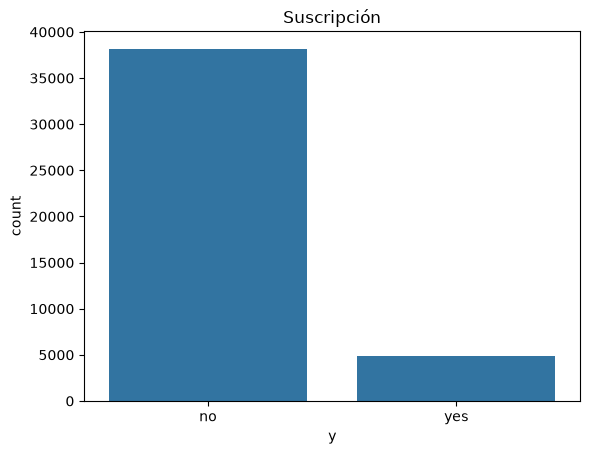

In [64]:
sns.countplot(data=df_bank_clientes, x='y')
plt.title('Suscripción')
plt.show()

*Perfil demográfico*

In [65]:
# Edad

df_bank_clientes['age'].describe()

count    43000.000000
mean        39.741698
std          9.817735
min         17.000000
25%         33.000000
50%         38.000000
75%         46.000000
max         98.000000
Name: age, dtype: float64

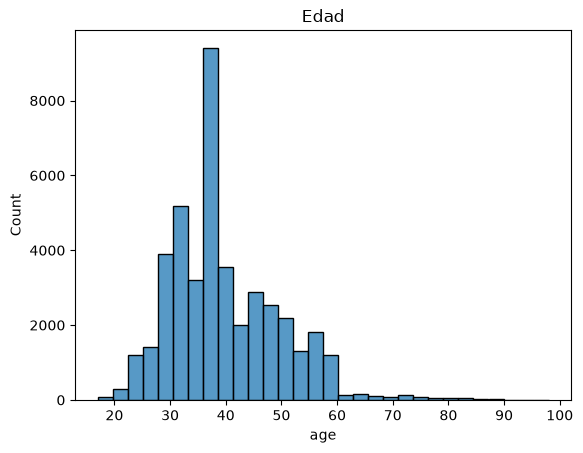

In [66]:
sns.histplot(df_bank_clientes['age'], bins=30)
plt.title('Edad')
plt.show()

*Estado Civil*

In [67]:
df_bank_clientes['marital'].value_counts()

marital
MARRIED     25999
SINGLE      12105
DIVORCED     4811
Unknown        85
Name: count, dtype: int64

In [68]:
df_bank_clientes['marital'].value_counts(normalize=True)*100

marital
MARRIED     60.462791
SINGLE      28.151163
DIVORCED    11.188372
Unknown      0.197674
Name: proportion, dtype: float64

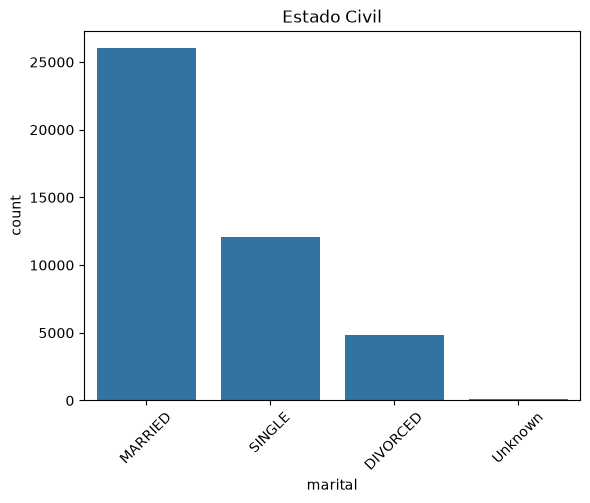

In [69]:
sns.countplot(data=df_bank_clientes, x='marital')
plt.title('Estado Civil')
plt.xticks(rotation=45)
plt.show()

*Profesión*

In [70]:
df_bank_clientes['job'].value_counts(normalize=True)*100

job
admin.           25.286047
blue-collar      22.451163
technician       16.339535
services          9.679070
management        7.093023
retired           4.162791
entrepreneur      3.539535
self-employed     3.462791
housemaid         2.611628
unemployed        2.472093
student           2.100000
Unknown           0.802326
Name: proportion, dtype: float64

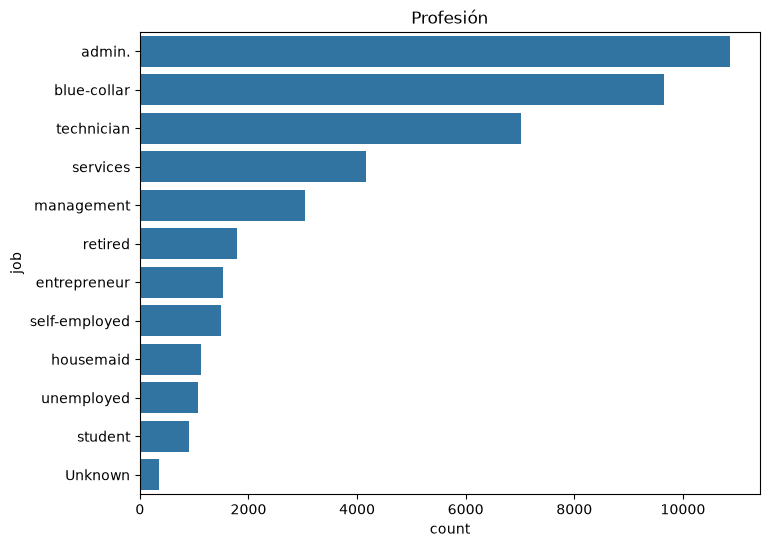

In [71]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df_bank_clientes,
    y='job',
    order=df_bank_clientes['job'].value_counts().index
)
plt.title('Profesión')
plt.show()

*Educación*

In [72]:
df_bank_clientes['education'].value_counts(normalize=True)*100

education
university.degree      29.586047
high.school            23.081395
basic.9y               14.672093
professional.course    12.737209
basic.4y               10.130233
basic.6y                5.548837
Unknown                 4.202326
illiterate              0.041860
Name: proportion, dtype: float64

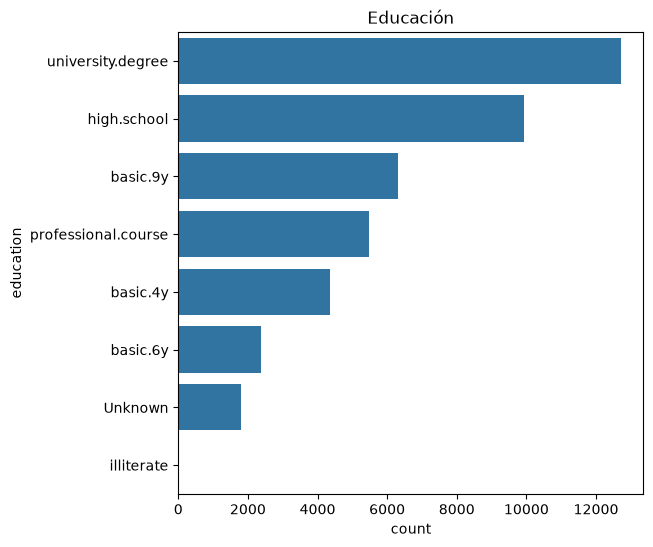

In [73]:
plt.figure(figsize=(6,6))

sns.countplot(
    data=df_bank_clientes,
    y='education',
    order=df_bank_clientes['education'].value_counts().index
)
plt.title('Educación')
plt.show()

*Características económicas*

In [74]:
# Income

df_bank_clientes['income'].describe()

count     43000.000000
mean      93241.200070
std       50498.316182
min        5841.000000
25%       49610.000000
50%       93050.500000
75%      136744.500000
max      180802.000000
Name: income, dtype: float64

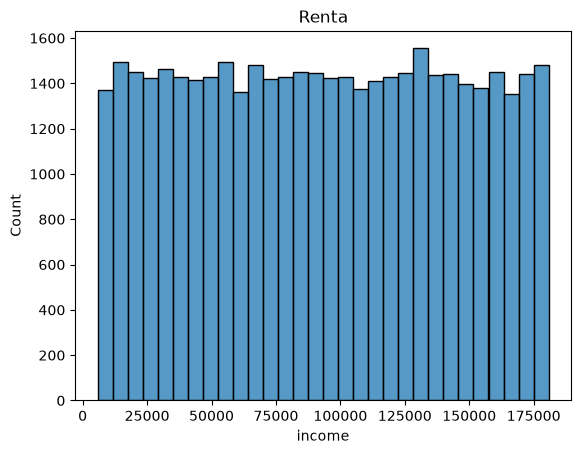

In [75]:
sns.histplot(df_bank_clientes['income'], bins=30)
plt.title('Renta')
plt.show()

In [76]:
# Euribor

df_bank_clientes['euribor3m'].describe()

count    33744.000000
mean         3.616521
std          1.737117
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64

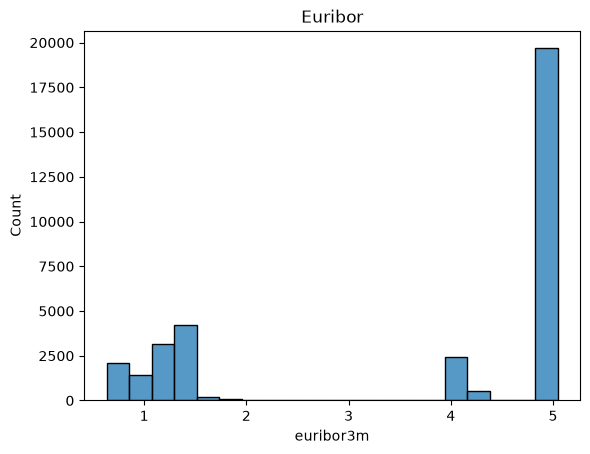

In [77]:
sns.histplot(df_bank_clientes['euribor3m'])
plt.title('Euribor')
plt.show()

*Variables de marketing*

In [78]:
# Duración de la llamada

df_bank_clientes['duration'].describe()

count    43000.000000
mean       257.739279
std        258.666033
min          0.000000
25%        102.000000
50%        179.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

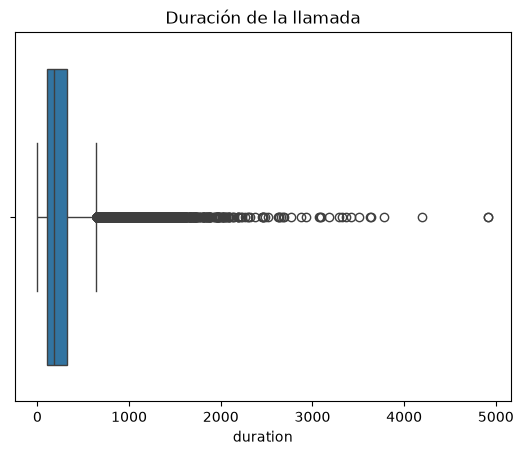

In [79]:
sns.boxplot(x=df_bank_clientes['duration'])
plt.title('Duración de la llamada')
plt.show()

In [80]:
# Número de contactos

df_bank_clientes['campaign'].describe()

count    43000.000000
mean         2.567233
std          2.772294
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

*Comparación con la contratación*

In [81]:
# Edad vs contratación

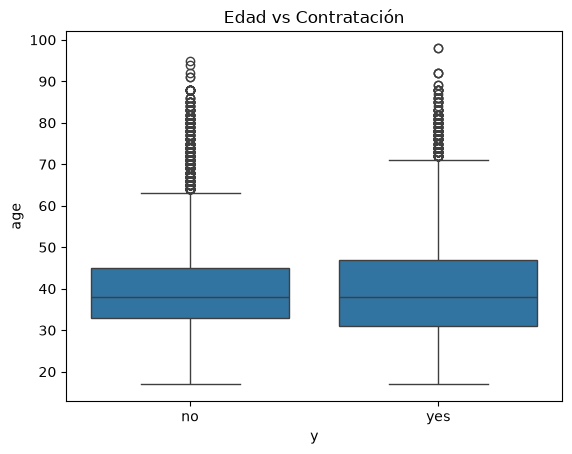

In [82]:
sns.boxplot(
    data=df_bank_clientes,
    x='y',
    y='age'
)
plt.title('Edad vs Contratación')
plt.show()

In [83]:
# Income vs contratación

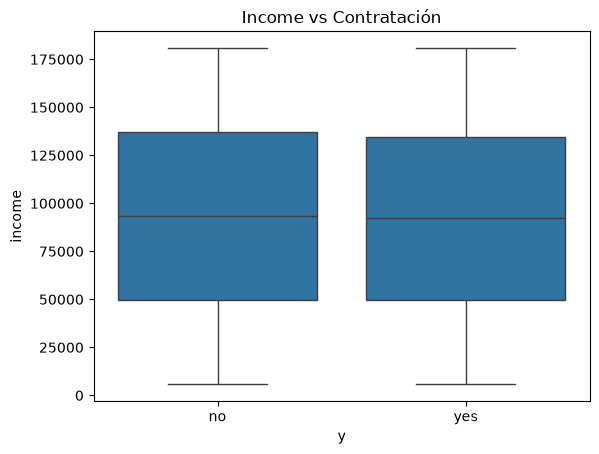

In [84]:
sns.boxplot(
    data=df_bank_clientes,
    x='y',
    y='income'
)
plt.title('Income vs Contratación')
plt.show()

In [85]:
# Euribor vs contratación

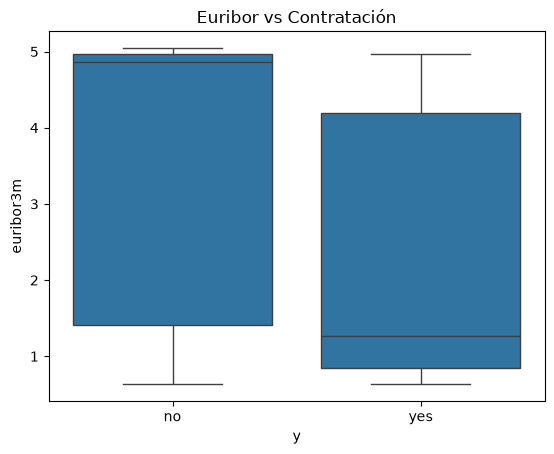

In [86]:
sns.boxplot(
    data=df_bank_clientes,
    x='y',
    y='euribor3m'
)
plt.title('Euribor vs Contratación')
plt.show()

In [87]:
# Profesión vs contratación

In [88]:
pd.crosstab(
    df_bank_clientes['job'],
    df_bank_clientes['y'],
    normalize='index'
)*100

y,no,yes
job,,
Unknown,88.695652,11.304348
admin.,86.986112,13.013888
blue-collar,93.111664,6.888336
entrepreneur,91.721419,8.278581
housemaid,90.115761,9.884239
management,88.786885,11.213115
retired,74.804469,25.195531
self-employed,89.187374,10.812626
services,91.926958,8.073042


In [89]:
# Estado civil vs contratación

In [90]:
pd.crosstab(
    df_bank_clientes['marital'],
    df_bank_clientes['y'],
    normalize='index'
)*100

y,no,yes
marital,,
DIVORCED,89.815007,10.184993
MARRIED,89.788069,10.211931
SINGLE,86.071871,13.928129
Unknown,84.705882,15.294118


*Correlaciones*

In [91]:
numericas = df_bank_clientes.select_dtypes(include=['int64', 'float64'])

In [92]:
numericas.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'latitude', 'longitude', 'contact_year', 'income', 'kidhome',
       'teenhome', 'numwebvisitsmonth'],
      dtype='str')

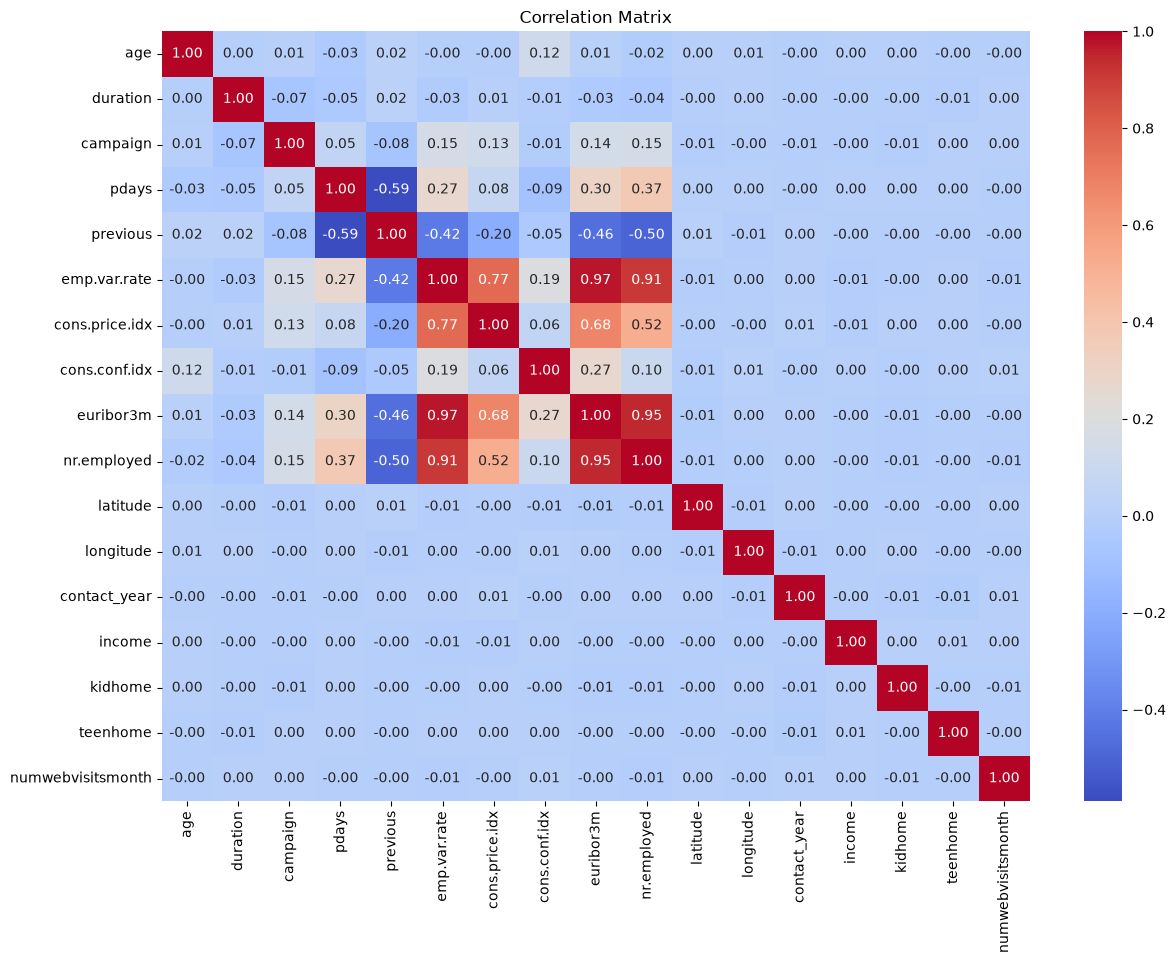

In [93]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numericas.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()